<a href="https://www.kaggle.com/code/matheusgabrielalves/ia-svm-perfil-tecnico-de-elite-fc-26-6b-noite?scriptVersionId=352564829" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise de Classificação com SVM
## EA Sports FC 26 — Identificação de Perfil Técnico de Elite

---

**Disciplina:** Inteligência Artificial  
**Curso:** Engenharia de Software  
**Turma:** 6B — Noite  
**Orientadores:** Prof. Fabiano Bezerra Menegidio e Prof. Higor Barreto Campos  
**Data:** 24/09/2026

---

### Integrantes

**Matheus Gabriel Alves da Silva** — RGM 11241100109  
**José Murilo de Sá Bezerra** — RGM 11241103548

## 1. Definição do Problema

**Tema:** identificar, a partir de atributos técnicos, se um jogador possui perfil compatível com as principais ligas europeias.

**Tipo:** classificação binária | **Algoritmo:** SVM

**Alvo:** `target` — 0 (ligas menores) / 1 (liga de elite)

**Preditores:** 37 atributos técnicos e físicos — ritmo, finalização, passe, drible, defesa, força e seus sub-atributos — além de posição e pé preferido.

**Baseline:** 70,21%. É a acurácia de chutar sempre a classe majoritária.

**Aplicação prática:** após treinar o modelo com jogadores já consolidados na carreira, aplicamos o classificador a jovens atletas de ligas menores para identificar quais já apresentam perfil técnico de elite — uma simulação de processo de observação técnica (*scouting*).

## 2. Importação do Dataset

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Localiza o arquivo do dataset anexado
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/talhademirezen/fc-26-player-stats/fc_26_players_stats.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/talhademirezen/fc-26-player-stats/fc_26_players_stats.csv")

df.head()

,page,slug,player_id,Name,Age,Nation,League,Team,Position,Preferred Foot,...,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Physicality,Jumping,Stamina,Strength,Aggression,source_url
0,1,mohamed-salah,209331,Mohamed Salah,33,Egypt,Premier League,Liverpool,RM,Left,...,59,38,43,41,76,79,88,75,63,https://www.ea.com/games/ea-sports-fc/ratings/...
1,1,kylian-mbappe,231747,Kylian Mbappé,26,France,LALIGA EA SPORTS,Real Madrid,ST,Right,...,78,26,34,32,76,90,83,77,61,https://www.ea.com/games/ea-sports-fc/ratings/...
2,1,ousmane-dembele,231443,Ousmane Dembélé,28,France,Ligue 1 McDonald's,Paris SG,ST,Left,...,74,49,49,39,69,84,76,69,58,https://www.ea.com/games/ea-sports-fc/ratings/...
3,1,rodri,231866,Rodri,29,Spain,Premier League,Manchester City,CDM,Right,...,81,88,87,82,85,83,91,83,85,https://www.ea.com/games/ea-sports-fc/ratings/...
4,1,virgil-van-dijk,203376,Virgil van Dijk,34,Holland,Premier League,Liverpool,CB,Right,...,88,91,91,87,87,89,75,93,85,https://www.ea.com/games/ea-sports-fc/ratings/...


## 3. Avaliação do Banco de Dados

Inspeção da estrutura, tipos de dados, valores ausentes e distribuição das variáveis.

In [3]:
print('Dimensões:', df.shape)
df.info()

Dimensões: (16234, 47)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16234 entries, 0 to 16233
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   page                16234 non-null  int64 
 1   slug                16234 non-null  object
 2   player_id           16234 non-null  int64 
 3   Name                16234 non-null  object
 4   Age                 16234 non-null  int64 
 5   Nation              16234 non-null  object
 6   League              16154 non-null  object
 7   Team                16043 non-null  object
 8   Position            16234 non-null  object
 9   Preferred Foot      16234 non-null  object
 10  Height              16234 non-null  int64 
 11  Weight              16234 non-null  int64 
 12  Pace                16234 non-null  int64 
 13  Acceleration        16234 non-null  int64 
 14  Sprint Speed        16234 non-null  int64 
 15  Shooting            16234 non-null  int64 
 16 

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

League     80
Team      191
dtype: int64

In [5]:
df.describe()

,page,player_id,Age,Height,Weight,Pace,Acceleration,Sprint Speed,Shooting,Positioning,...,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Physicality,Jumping,Stamina,Strength,Aggression
count,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,...,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000,16234.000000
mean,81.605950,215655.066096,25.774301,182.099544,75.278182,68.155723,64.671492,64.858815,54.355981,51.172478,...,47.344832,52.141493,46.897930,48.963287,46.699951,65.217322,66.250339,63.289701,65.325736,56.360293
std,46.871133,68192.418993,4.687992,6.900509,6.938358,10.436350,15.464737,15.253735,13.725494,20.077290,...,20.927548,17.404253,20.662516,21.043753,20.613025,9.464838,11.807228,16.493096,12.237706,16.638387
min,1.000000,19541.000000,17.000000,155.000000,47.000000,30.000000,15.000000,14.000000,21.000000,3.000000,...,6.000000,6.000000,5.000000,8.000000,6.000000,32.000000,27.000000,12.000000,25.000000,11.000000
25%,41.000000,209238.000000,22.000000,177.000000,70.000000,62.000000,57.000000,58.000000,45.000000,41.000000,...,26.000000,45.000000,29.000000,29.000000,27.000000,59.000000,59.000000,56.000000,58.000000,47.000000
50%,82.000000,241140.500000,25.000000,182.000000,75.000000,69.000000,68.000000,68.000000,57.000000,57.000000,...,55.000000,55.000000,54.000000,57.000000,54.000000,66.000000,68.000000,67.000000,66.000000,60.000000
75%,122.000000,261778.250000,29.000000,187.000000,80.000000,75.000000,75.000000,75.000000,64.000000,65.000000,...,64.000000,64.000000,64.000000,66.000000,64.000000,72.000000,75.000000,74.000000,74.000000,68.000000
max,163.000000,279948.000000,44.000000,210.000000,105.000000,97.000000,97.000000,97.000000,92.000000,95.000000,...,91.000000,94.000000,91.000000,91.000000,89.000000,91.000000,95.000000,95.000000,95.000000,94.000000


In [6]:
print("Duplicadas:", df.duplicated().sum())
print()
for col in ['Position', 'Preferred Foot', 'League', 'Nation', 'Team']:
    print(f"{col}: {df[col].nunique()} categorias")

print()
print("--- Position ---")
print(df['Position'].value_counts())

Duplicadas: 0

Position: 12 categorias
Preferred Foot: 2 categorias
League: 47 categorias
Nation: 155 categorias
Team: 631 categorias

--- Position ---
Position
CB     2951
ST     2234
CM     1978
GK     1816
RB     1273
CDM    1268
LB     1210
LM      971
CAM     964
RM      902
RW      338
LW      329
Name: count, dtype: int64


In [7]:
print("--- Ligas mais frequentes ---")
print(df['League'].value_counts().head(12))

--- Ligas mais frequentes ---
League
LPF                   869
MLS                   770
EFL Championship      650
EFL League One        650
EFL League Two        605
Premier League        540
Serie A Enilive       531
3                     523
Bundesliga            515
Bundesliga 2          508
LALIGA EA SPORTS      500
LALIGA HYPERMOTION    462
Name: count, dtype: int64


**Achados da avaliação:**

- **Dimensões:** 16.234 registros × 47 colunas
- **Duplicadas:** nenhuma
- **Ausentes:** 80 em `League` e 191 em `Team`
- **Atributos técnicos:** 37 colunas numéricas, todas em escala de 1 a 99
- **Alta cardinalidade:** `Team` (631 categorias), `Nation` (155) e `League` (47)
- **Colunas sem valor preditivo:** `page`, `slug`, `player_id`, `Name` e `source_url` são identificadores ou metadados de coleta
- **Posições:** 12 categorias bem distribuídas, incluindo 1.816 goleiros

### 3.1 Análise Visual Exploratória

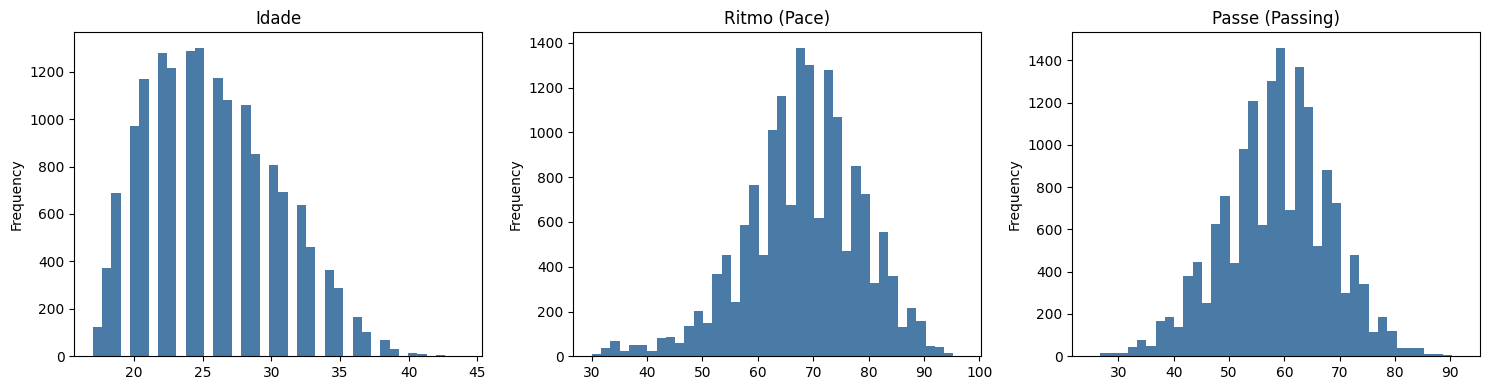

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, titulo in zip(axes, ['Age', 'Pace', 'Passing'],
                           ['Idade', 'Ritmo (Pace)', 'Passe (Passing)']):
    df[col].plot(kind='hist', bins=40, ax=ax, color='#4a7ba7')
    ax.set_title(titulo)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

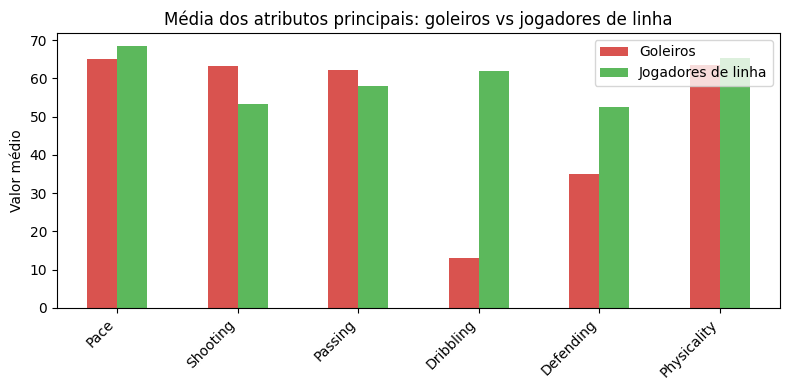

             Goleiros  Jogadores de linha
Pace             65.1                68.5
Shooting         63.2                53.2
Passing          62.3                58.1
Dribbling        13.1                61.9
Defending        34.9                52.5
Physicality      63.6                65.4


In [9]:
principais = ['Pace', 'Shooting', 'Passing', 'Dribbling', 'Defending', 'Physicality']

comparacao = pd.DataFrame({
    'Goleiros': df[df['Position'] == 'GK'][principais].mean(),
    'Jogadores de linha': df[df['Position'] != 'GK'][principais].mean()
}).round(1)

comparacao.plot(kind='bar', figsize=(8, 4), color=['#d9534f', '#5cb85c'])
plt.title('Média dos atributos principais: goleiros vs jogadores de linha')
plt.ylabel('Valor médio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(comparacao)

**Leitura dos gráficos:**

- A idade concentra-se entre 20 e 30 anos, com cauda até os 44.
- Os atributos técnicos seguem distribuição aproximadamente normal.
- **A comparação entre goleiros e jogadores de linha revela uma inconsistência estrutural:** goleiros apresentam média de 13,1 em `Dribbling` contra 61,9 dos demais. No jogo, goleiros possuem seis atributos próprios (mergulho, defesa com as mãos, reflexos, chute, posicionamento e velocidade), mas o dataset reaproveita os nomes das colunas de jogadores de linha. Os valores, portanto, **não são comparáveis entre os dois grupos**.

## 4. Tratativa de Colunas Irrelevantes

Removemos sete colunas que não contribuem para a classificação:

- **Identificadores e metadados:** `page`, `slug`, `player_id` e `source_url` — referem-se ao processo de coleta dos dados, não ao jogador
- **Alta cardinalidade:** `Team` (631 categorias) e `Nation` (155) — codificadas, gerariam centenas de colunas com pouquíssimos registros cada

A coluna `Name` é mantida ao longo do pré-processamento apenas como identificação, para que possamos exibir os jogadores na etapa de aplicação. Ela **não entra como variável preditora** — é removida na montagem da matriz de features.

In [10]:
irrelevantes = ['page', 'slug', 'player_id', 'source_url', 'Team', 'Nation']

df = df.drop(columns=irrelevantes)
print("Dimensões após remoção:", df.shape)
print("\nColunas restantes:")
print(df.columns.tolist())

Dimensões após remoção: (16234, 41)

Colunas restantes:
['Name', 'Age', 'League', 'Position', 'Preferred Foot', 'Height', 'Weight', 'Pace', 'Acceleration', 'Sprint Speed', 'Shooting', 'Positioning', 'Finishing', 'Shot Power', 'Long Shots', 'Volleys', 'Penalties', 'Passing', 'Vision', 'Crossing', 'Free Kick Accuracy', 'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility', 'Balance', 'Reactions', 'Ball Control', 'Composure', 'Defending', 'Interceptions', 'Heading Accuracy', 'Def Awareness', 'Standing Tackle', 'Sliding Tackle', 'Physicality', 'Jumping', 'Stamina', 'Strength', 'Aggression']


## 5. Tratativa de Inconsistência de Escala — Goleiros

Conforme identificado na análise exploratória, as colunas de atributos possuem significados diferentes para goleiros e jogadores de linha. `Dribbling` vale em média 13,1 para goleiros e 61,9 para os demais; `Defending`, 34,9 contra 52,5.

Manter os dois grupos na mesma base faria o modelo aprender a distinguir goleiros dos demais jogadores, em vez de aprender o que caracteriza o nível competitivo — objetivo desta análise.

**Decisão:** removemos os 1.816 goleiros. Uma análise voltada a esse grupo exigiria um modelo próprio, treinado sobre os atributos específicos da posição.

In [11]:
print("Goleiros na base:", (df['Position'] == 'GK').sum())

df = df[df['Position'] != 'GK'].reset_index(drop=True)

print("Dimensões após remoção:", df.shape)
print("\nPosições restantes:")
print(df['Position'].value_counts())

Goleiros na base: 1816
Dimensões após remoção: (14418, 41)

Posições restantes:
Position
CB     2951
ST     2234
CM     1978
RB     1273
CDM    1268
LB     1210
LM      971
CAM     964
RM      902
RW      338
LW      329
Name: count, dtype: int64


## 6. Tratativa de Dados Ausentes

Após a remoção dos goleiros, restam 71 registros sem informação de liga.

A variável `League` é a origem do nosso alvo — sem ela, não há como determinar a classe do registro. Imputar um valor seria inventar a resposta que o modelo deve aprender.

**Decisão:** removemos esses registros. Correspondem a 0,5% da base, percentual que não compromete a amostra.

In [12]:
print("Valores ausentes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

antes = len(df)
df = df[df['League'].notna()].reset_index(drop=True)

print(f"\nRegistros removidos: {antes - len(df)} ({(antes - len(df))/antes*100:.1f}%)")
print("Total de nulos restantes:", df.isnull().sum().sum())
print("Dimensões:", df.shape)

Valores ausentes:
League    71
dtype: int64

Registros removidos: 71 (0.5%)
Total de nulos restantes: 0
Dimensões: (14347, 41)


## 7. Definição do Alvo

A coluna `League` possui 47 categorias com níveis competitivos muito distintos. Para construir um alvo binário coerente, selecionamos dois grupos de referência:

- **Ligas de elite:** Premier League, LaLiga, Ligue 1, Bundesliga e Serie A — as cinco principais competições europeias
- **Ligas menores:** divisões inferiores e campeonatos de menor projeção — EFL Championship, League One, League Two, Ligue 2, Bundesliga 2, LaLiga Hypermotion, Serie B, MLS e LPF

Ligas de posição intermediária foram excluídas do recorte. Incluí-las tornaria a fronteira entre as classes ambígua, já que não há consenso sobre a qual grupo pertencem.

In [13]:
elite = ['Premier League', 'LALIGA EA SPORTS', "Ligue 1 McDonald's",
         'Bundesliga', 'Serie A Enilive']

menores = ['EFL Championship', 'EFL League One', 'EFL League Two', 'Ligue 2 BKT',
           'Bundesliga 2', 'LALIGA HYPERMOTION', 'Serie BKT', 'MLS', 'LPF', '3']

df['target'] = df['League'].isin(elite).astype(int)

# Base de modelagem: apenas os dois extremos do espectro competitivo
modelagem = df[df['League'].isin(elite + menores)].copy()

print("Base completa:", df.shape)
print("Base de modelagem (recorte por liga):", modelagem.shape)
print("\nDistribuição do alvo na base de modelagem:")
print(modelagem['target'].value_counts())
print(modelagem['target'].value_counts(normalize=True).round(4))

Base completa: (14347, 42)
Base de modelagem (recorte por liga): (7529, 42)

Distribuição do alvo na base de modelagem:
target
0    5280
1    2249
Name: count, dtype: int64
target
0    0.7013
1    0.2987
Name: proportion, dtype: float64


### 7.1 Separação entre Base de Treino e Base de Aplicação

Esta é a decisão metodológica central do trabalho.

O modelo será treinado **apenas com jogadores de 24 anos ou mais** — atletas cuja carreira já se definiu, e cuja liga atual reflete o nível competitivo que alcançaram.

Os jogadores de até 20 anos ficam reservados para a etapa de aplicação. Eles **não participam do treinamento nem da avaliação**, o que elimina qualquer circularidade: o modelo nunca viu esses atletas ao aprender o que caracteriza um jogador de elite.

Essa separação é o que torna a aplicação de *scouting* metodologicamente válida.

In [14]:
# Treino: jogadores consolidados, dentro do recorte de ligas
consolidados = modelagem[modelagem['Age'] >= 24].copy()

# Aplicação: jovens de TODAS as ligas, para não restringir a busca por talentos
jovens = df[df['Age'] <= 20].copy()

print("Base de treino (24+ anos):", len(consolidados))
print("Base de aplicação (até 20 anos):", len(jovens))
print("\nDistribuição do alvo na base de treino:")
print(consolidados['target'].value_counts())
print(consolidados['target'].value_counts(normalize=True).round(4))

Base de treino (24+ anos): 4757
Base de aplicação (até 20 anos): 1942

Distribuição do alvo na base de treino:
target
0    3340
1    1417
Name: count, dtype: int64
target
0    0.7021
1    0.2979
Name: proportion, dtype: float64


### 7.2 Distribuição e Separação das Classes

Visualizamos como as classes se distribuem na base de modelagem e como os principais atributos se comportam em cada uma delas.

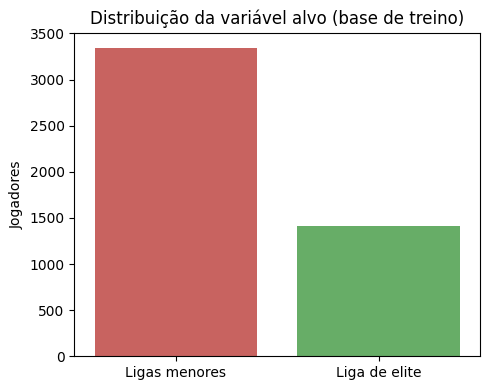

In [15]:
plt.figure(figsize=(5, 4))

sns.countplot(
    data=consolidados,
    x='target',
    hue='target',
    palette=['#d9534f', '#5cb85c'],
    legend=False
)

plt.title('Distribuição da variável alvo (base de treino)')
plt.xticks([0, 1], ['Ligas menores', 'Liga de elite'])
plt.xlabel('')
plt.ylabel('Jogadores')
plt.tight_layout()
plt.show()

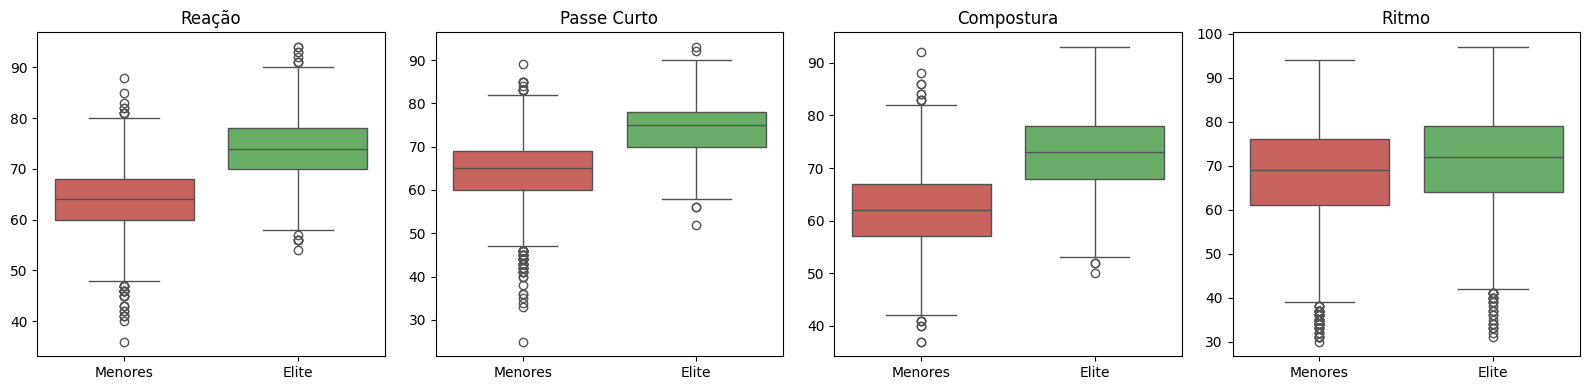

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

cols = ['Reactions', 'Short Passing', 'Composure', 'Pace']
nomes = ['Reação', 'Passe Curto', 'Compostura', 'Ritmo']

for ax, col, nome in zip(axes, cols, nomes):
    sns.boxplot(
        data=consolidados,
        x='target',
        y=col,
        hue='target',
        ax=ax,
        palette=['#d9534f', '#5cb85c'],
        legend=False
    )
    ax.set_title(nome)
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Menores', 'Elite'])
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Leitura dos gráficos:**

- A base de treino apresenta 70% de jogadores de ligas menores contra 30% de ligas de elite — desbalanceamento moderado, tratado na seção 15.
- `Reactions`, `Short Passing` e `Composure` mostram separação nítida entre as classes: as caixas quase não se sobrepõem.
- `Pace` é o contraste: as distribuições são praticamente iguais nos dois grupos. Velocidade não distingue o nível competitivo.
- Ainda assim, há sobreposição em todos os atributos — nenhum isolado determina a classificação, o que justifica o uso de um classificador multivariado como o SVM.

## 8. Tratativa de Encoding

Duas colunas permanecem como texto e precisam ser convertidas, pois o SVM opera apenas sobre dados numéricos:

- `Preferred Foot` — 2 categorias (Right / Left)
- `Position` — 11 categorias, após a remoção dos goleiros

**Decisão:** aplicamos one-hot encoding (`pd.get_dummies`) com `drop_first=True`. Nenhuma das duas possui ordem natural — atribuir 0, 1, 2 às posições criaria uma hierarquia inexistente, levando o modelo a interpretar que um atacante é "maior" que um zagueiro. O parâmetro `drop_first` descarta uma categoria de cada variável para evitar colinearidade perfeita.

Removemos também `League`, que originou o alvo, e `Age`, utilizada apenas para separar as bases.

In [17]:
print("Categorias a codificar:")
print("  Preferred Foot:", consolidados['Preferred Foot'].nunique())
print("  Position:", consolidados['Position'].nunique())

dados = consolidados.drop(columns=['League', 'Age', 'Name'])
dados = pd.get_dummies(dados, columns=['Preferred Foot', 'Position'],
                        drop_first=True, dtype=int)

print("\nDimensões após encoding:", dados.shape)
print("\nColunas geradas:")
print([c for c in dados.columns if c.startswith(('Preferred', 'Position_'))])

Categorias a codificar:
  Preferred Foot: 2
  Position: 11

Dimensões após encoding: (4757, 48)

Colunas geradas:
['Preferred Foot_Right', 'Position_CB', 'Position_CDM', 'Position_CM', 'Position_LB', 'Position_LM', 'Position_LW', 'Position_RB', 'Position_RM', 'Position_RW', 'Position_ST']


## 9. Validação Final

In [18]:
print("Colunas do tipo texto restantes:", dados.select_dtypes(include='object').shape[1])
print("Valores nulos:", dados.isnull().sum().sum())
print("Duplicadas:", dados.duplicated().sum())
print("Dimensões finais:", dados.shape)
print("\nTipos de dados:")
print(dados.dtypes.value_counts())

Colunas do tipo texto restantes: 0
Valores nulos: 0
Duplicadas: 0
Dimensões finais: (4757, 48)

Tipos de dados:
int64    48
Name: count, dtype: int64


### 9.1 Matriz de Correlação

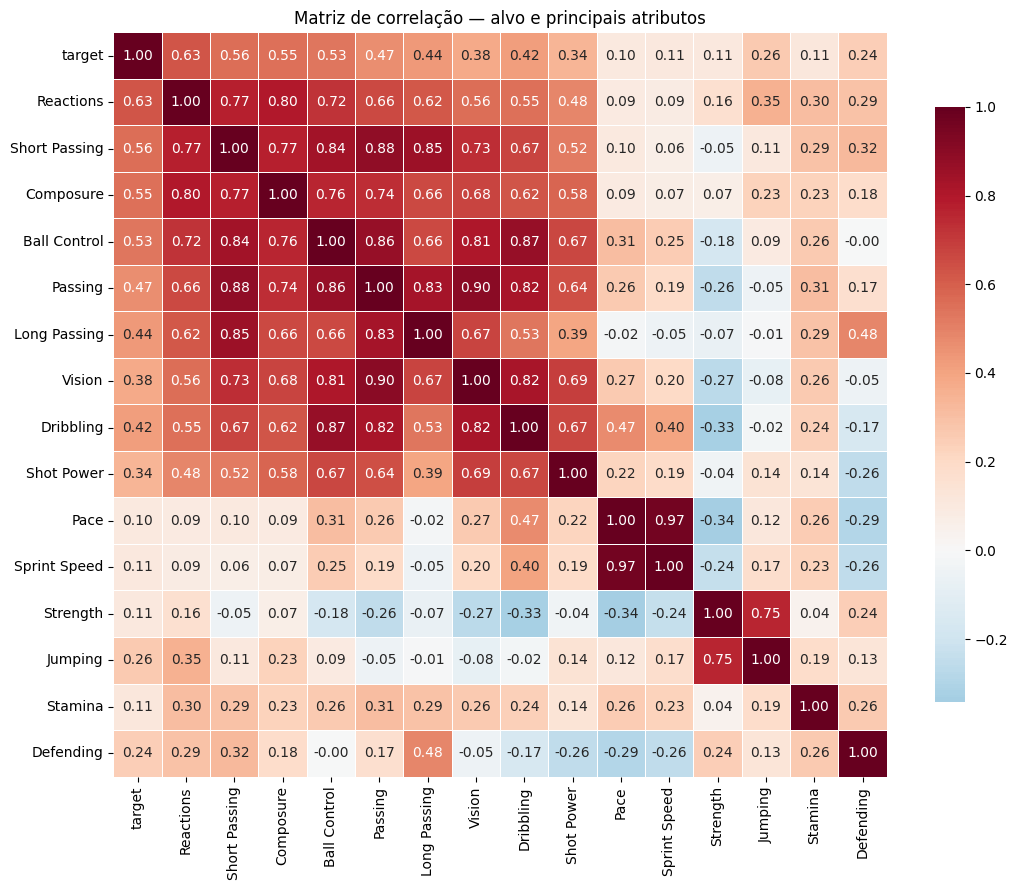

In [19]:
plt.figure(figsize=(11, 9))

principais = ['target', 'Reactions', 'Short Passing', 'Composure', 'Ball Control',
              'Passing', 'Long Passing', 'Vision', 'Dribbling', 'Shot Power',
              'Pace', 'Sprint Speed', 'Strength', 'Jumping', 'Stamina', 'Defending']

sns.heatmap(
    dados[principais].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de correlação — alvo e principais atributos')
plt.tight_layout()
plt.show()

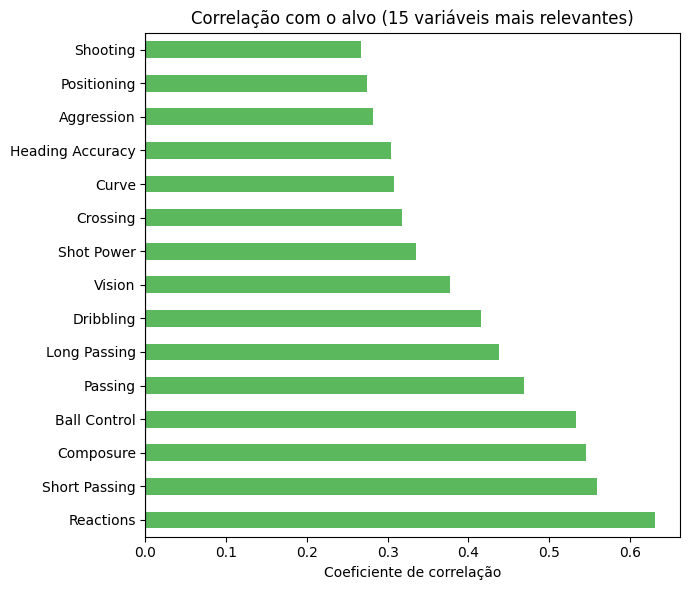

Reactions           0.631
Short Passing       0.559
Composure           0.546
Ball Control        0.533
Passing             0.469
Long Passing        0.438
Dribbling           0.415
Vision              0.377
Shot Power          0.336
Crossing            0.318
Curve               0.308
Heading Accuracy    0.305
Aggression          0.281
Positioning         0.274
Shooting            0.267
Name: target, dtype: float64


In [20]:
corr = dados.corr()['target'].drop('target').sort_values(key=abs, ascending=False).head(15)

plt.figure(figsize=(7, 6))
cores = ['#5cb85c' if v > 0 else '#d9534f' for v in corr]
corr.plot(kind='barh', color=cores)

plt.title('Correlação com o alvo (15 variáveis mais relevantes)')
plt.xlabel('Coeficiente de correlação')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(corr.round(3))

**Leitura da correlação:**

- `Reactions` (+0,63), `Short Passing` (+0,56), `Composure` (+0,55) e `Ball Control` (+0,53) lideram
- `Passing` (+0,47), `Long Passing` (+0,44) e `Vision` (+0,38) reforçam o mesmo padrão
- Atributos físicos como `Pace`, `Strength` e `Jumping` aparecem bem abaixo

**O que distingue um jogador de liga de elite não é velocidade nem força física, mas leitura de jogo.** Reação, precisão de passe, compostura sob pressão e controle de bola concentram o poder discriminante. Esse resultado contraria a percepção comum de que o futebol de alto nível se define por atributos atléticos.

## 10. Limitações Identificadas

- **Dados de videogame:** os atributos são atribuições da EA Sports, não medições objetivas de desempenho em campo. Refletem a percepção dos avaliadores sobre cada jogador.

- **Circularidade parcial:** é possível que a EA atribua notas mais altas a jogadores de ligas de elite pela própria visibilidade dessas competições, e não apenas por desempenho técnico. Esse viés não pode ser descartado com os dados disponíveis.

- **Recorte de ligas:** a classificação em "elite" e "menores" exclui competições intermediárias. A fronteira adotada é uma simplificação.

- **O modelo não prevê o futuro:** identifica compatibilidade técnica com o nível de elite no momento atual. Um jogador apontado pode não se desenvolver, e outro fora da lista pode evoluir — o modelo mede perfil, não potencial.

## 11. Conclusão da Etapa 1 — 16/09/2026

Concluímos a preparação da base para a modelagem:

- **Colunas irrelevantes removidas:** 7
- **Goleiros removidos:** 1.816 (escala de atributos incompatível)
- **Registros sem liga removidos:** 71
- **Recorte por nível competitivo (base de modelagem):** 7.529 jogadores
- **Base de treino (24+ anos):** 4.757 registros
- **Base de aplicação (até 20 anos, todas as ligas):** reservada para a etapa final
- **Variáveis codificadas:** 2 (`Preferred Foot` e `Position`)
- **Colunas do tipo texto restantes:** 0

## 12. Divisão dos Dados em Treino e Teste — 17/09/2026

Separação de 80% para treino e 20% para teste, com estratificação para preservar a proporção das classes em ambos os conjuntos.

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
X = dados.drop('target', axis=1)
y = dados['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nProporção no treino:")
print(y_train.value_counts(normalize=True).round(4))
print("\nProporção no teste:")
print(y_test.value_counts(normalize=True).round(4))

Treino: (3805, 47) | Teste: (952, 47)

Proporção no treino:
target
0    0.7022
1    0.2978
Name: proportion, dtype: float64

Proporção no teste:
target
0    0.7017
1    0.2983
Name: proportion, dtype: float64


### 12.1 Padronização das Variáveis

Aplicamos a padronização porque o SVM é sensível à escala dos dados. Embora os atributos técnicos compartilhem a escala de 1 a 99, as variáveis binárias criadas pelo one-hot encoding assumem apenas 0 ou 1 — sem padronização, os atributos de maior magnitude dominariam o cálculo do kernel.

Ajustamos o `StandardScaler` apenas no conjunto de treino e o aplicamos ao teste em seguida. Se o ajustássemos sobre a base completa, informações do conjunto de teste influenciariam a transformação do treino, caracterizando vazamento de dados.

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Média após padronização:", round(X_train_scaled.mean(), 4))
print("Desvio padrão após padronização:", round(X_train_scaled.std(), 4))

Média após padronização: -0.0
Desvio padrão após padronização: 1.0


## 13. Otimização de Hiperparâmetros com GridSearchCV

Realizamos uma busca exaustiva pela melhor combinação de hiperparâmetros, com validação cruzada de 5 dobras:

- `C` — penalidade por erro de classificação. Valores altos ajustam mais a fronteira aos dados de treino, com risco de overfitting.
- `gamma` — alcance de influência de cada amostra no kernel RBF.
- `kernel` — formato da fronteira de decisão, linear ou não linear.

A grade resulta em 12 combinações que, multiplicadas pelas 5 dobras, totalizam 60 treinamentos.

In [24]:
param_grid = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Melhores hiperparâmetros:", grid_search.best_params_)
print(f"Acurácia média na validação cruzada: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Melhores hiperparâmetros: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia média na validação cruzada: 0.8857


## 14. Treinamento e Avaliação no Conjunto de Teste

In [25]:
modelo = grid_search.best_estimator_
y_pred = modelo.predict(X_test_scaled)

acuracia = accuracy_score(y_test, y_pred)
baseline = y_test.value_counts(normalize=True).max()

print(f"Acurácia no teste: {acuracia:.4f}")
print(f"Baseline (classe majoritária): {baseline:.4f}")
print(f"Ganho sobre o baseline: {(acuracia - baseline) * 100:.2f} pontos percentuais")
print()
print(classification_report(y_test, y_pred,
                            target_names=['Ligas menores', 'Liga de elite'],
                            digits=3))

Acurácia no teste: 0.8803
Baseline (classe majoritária): 0.7017
Ganho sobre o baseline: 17.86 pontos percentuais

               precision    recall  f1-score   support

Ligas menores      0.876     0.966     0.919       668
Liga de elite      0.894     0.680     0.772       284

     accuracy                          0.880       952
    macro avg      0.885     0.823     0.845       952
 weighted avg      0.881     0.880     0.875       952



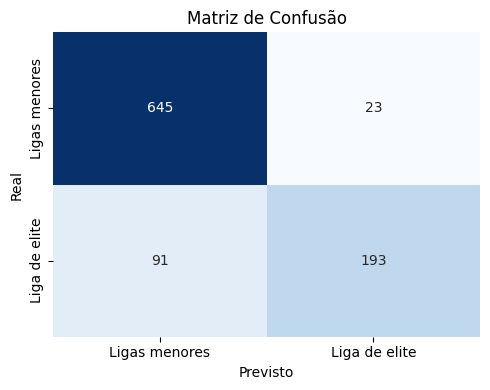

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ligas menores', 'Liga de elite'],
    yticklabels=['Ligas menores', 'Liga de elite'],
    cbar=False
)
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

**Leitura dos resultados:**

- **Acurácia:** 88,03%, contra baseline de 70,17% no conjunto de teste — ganho de 17,9 pontos percentuais
- **Kernel vencedor:** RBF, indicando fronteira não linear entre as classes
- **Precisão na classe elite:** 0,894 — quando o modelo aponta um jogador como perfil de elite, acerta em 89% dos casos
- **Sensibilidade na classe elite:** 0,680 — identifica 68% dos jogadores que realmente atuam em ligas de elite

O modelo é conservador: erra pouco ao apontar, mas deixa escapar parte dos jogadores de elite. Esse comportamento decorre do desbalanceamento de 70/30, tratado na seção seguinte.

## 15. Tratamento do Desbalanceamento — 23/09/2026

A base de treino apresenta 70% de jogadores de ligas menores contra 30% de ligas de elite. Esse desequilíbrio faz o SVM favorecer a classe majoritária.

O parâmetro `class_weight='balanced'` atribui peso maior aos erros na classe minoritária, forçando o modelo a prestar mais atenção nela. Comparamos as duas configurações.

In [27]:
modelo_bal = SVC(random_state=42, class_weight='balanced', **grid_search.best_params_)
modelo_bal.fit(X_train_scaled, y_train)
y_pred_bal = modelo_bal.predict(X_test_scaled)

print("=== MODELO PADRÃO ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred,
                            target_names=['Ligas menores', 'Liga de elite'], digits=3))

print("=== MODELO COM class_weight='balanced' ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_bal):.4f}")
print(classification_report(y_test, y_pred_bal,
                            target_names=['Ligas menores', 'Liga de elite'], digits=3))

=== MODELO PADRÃO ===
Acurácia: 0.8803
               precision    recall  f1-score   support

Ligas menores      0.876     0.966     0.919       668
Liga de elite      0.894     0.680     0.772       284

     accuracy                          0.880       952
    macro avg      0.885     0.823     0.845       952
 weighted avg      0.881     0.880     0.875       952

=== MODELO COM class_weight='balanced' ===
Acurácia: 0.8634
               precision    recall  f1-score   support

Ligas menores      0.919     0.883     0.901       668
Liga de elite      0.748     0.817     0.781       284

     accuracy                          0.863       952
    macro avg      0.834     0.850     0.841       952
 weighted avg      0.868     0.863     0.865       952



**Comparação:**

- **Modelo padrão** — acurácia 88,03%; na classe elite, precisão 0,894 e sensibilidade 0,680
- **Modelo balanceado** — acurácia 86,34%; na classe elite, precisão 0,748 e sensibilidade 0,817

O balanceamento eleva a sensibilidade de 0,680 para 0,817: o modelo passa a identificar 82% dos jogadores de elite, contra 68% anteriormente. Em contrapartida, a precisão cai de 0,894 para 0,748 — mais jogadores são apontados indevidamente.

**Para a aplicação de scouting adotamos o modelo padrão.** Em observação técnica, um falso positivo custa caro: a comissão desloca observadores e negocia com um atleta que não corresponde ao perfil. A precisão mais alta é preferível à cobertura mais ampla.

## 16. Validação Externa do Modelo

Antes de aplicar o modelo em jogadores desconhecidos, verificamos se ele reconhece jovens que **já chegaram** às ligas de elite. Esses atletas têm até 20 anos e não participaram do treinamento — o modelo foi treinado exclusivamente com jogadores de 24 anos ou mais.

Se o classificador atribuir alta probabilidade a esses jovens, confirma-se que aprendeu o padrão técnico do alto nível, e não apenas memorizou os registros de treino.

In [28]:
modelo_prob = SVC(probability=True, random_state=42, **grid_search.best_params_)
modelo_prob.fit(X_train_scaled, y_train)

# Jovens que JÁ atuam em ligas de elite
jovens_elite = jovens[jovens['target'] == 1].copy()

Xj = jovens_elite.drop(columns=['League', 'Age', 'target', 'Name'])
Xj = pd.get_dummies(Xj, columns=['Preferred Foot', 'Position'], drop_first=True, dtype=int)
Xj = Xj.reindex(columns=X.columns, fill_value=0)

jovens_elite['probabilidade'] = modelo_prob.predict_proba(scaler.transform(Xj))[:, 1]

print(f"Jovens avaliados: {len(jovens_elite)}")
print(f"Probabilidade média atribuída: {jovens_elite['probabilidade'].mean()*100:.1f}%")
print()
print("=== 10 maiores probabilidades ===")
top = jovens_elite.nlargest(10, 'probabilidade')[['Name', 'Age', 'Position', 'League', 'probabilidade']]
top['probabilidade'] = (top['probabilidade'] * 100).round(1)
print(top.to_string(index=False))

Jovens avaliados: 306
Probabilidade média atribuída: 25.1%

=== 10 maiores probabilidades ===
                  Name  Age Position           League  probabilidade
          Dean Huijsen   20       CB LALIGA EA SPORTS           99.4
           Pau Cubarsí   18       CB LALIGA EA SPORTS           99.3
             Leny Yoro   19       CB   Premier League           98.2
           Jorrel Hato   19       LB   Premier League           98.1
            Rico Lewis   20       RB   Premier League           97.8
          Kenan Yıldız   20      CAM  Serie A Enilive           96.0
          Lamine Yamal   18       RM LALIGA EA SPORTS           96.0
           Marc Bernal   18      CDM LALIGA EA SPORTS           94.8
            Arda Güler   20       RM LALIGA EA SPORTS           94.3
El Chadaille Bitshiabu   20       CB       Bundesliga           94.2


**Resultado:** o topo da lista reúne jovens já consolidados nas principais equipes europeias, com probabilidades acima de 94% — apesar de nenhum deles ter participado do treinamento.

A probabilidade média do grupo é mais baixa porque nem todo jovem de um clube de elite já apresenta o perfil técnico completo: muitos ainda estão em formação. O que valida o modelo é o extremo superior da distribuição, onde aparecem exatamente os nomes que o mercado reconhece como já estabelecidos.

A validação externa confirma que o classificador aprendeu o padrão técnico do alto nível, e não memorizou a amostra de treino.

## 17. Aplicação — Observação Técnica de Jovens Atletas

Com o modelo validado, aplicamos o classificador aos jogadores de até 20 anos que atuam **fora** das ligas de elite.

A pergunta que o modelo responde: *quais jovens de divisões menores já apresentam o perfil técnico dos jogadores de alto nível?*

In [29]:
# Jovens que ainda NÃO atuam em ligas de elite
jovens_fora = jovens[jovens['target'] == 0].copy()

Xf = jovens_fora.drop(columns=['League', 'Age', 'target', 'Name'])
Xf = pd.get_dummies(Xf, columns=['Preferred Foot', 'Position'], drop_first=True, dtype=int)
Xf = Xf.reindex(columns=X.columns, fill_value=0)

jovens_fora['probabilidade'] = modelo_prob.predict_proba(scaler.transform(Xf))[:, 1]

print(f"Jovens avaliados: {len(jovens_fora)}")
print(f"Classificados com perfil de elite (prob > 50%): {(jovens_fora['probabilidade'] > 0.5).sum()}")
print()
print("=== 15 MAIORES PROBABILIDADES ===")
top15 = jovens_fora.nlargest(15, 'probabilidade')[['Name', 'Age', 'Position', 'League', 'probabilidade']]
top15['probabilidade'] = (top15['probabilidade'] * 100).round(1)
print(top15.to_string(index=False))

Jovens avaliados: 1636
Classificados com perfil de elite (prob > 50%): 15

=== 15 MAIORES PROBABILIDADES ===
               Name  Age Position             League  probabilidade
         Gustavo Sá   20      CAM      Liga Portugal           95.3
              Yarek   20       CB         Eredivisie           93.4
   Martim Fernandes   19       RB      Liga Portugal           93.0
    Roger Fernandes   19       RM ROSHN Saudi League           85.9
      Lucas Stassin   20       ST        Ligue 2 BKT           81.6
  Youssoufa Moukoko   20       ST       3F Superliga           64.6
       Rodrigo Mora   18      CAM      Liga Portugal           64.6
     Taras Mykhavko   20       CB      Ukrayina Liha           63.9
       Givairo Read   19       RB         Eredivisie           62.9
        Nathan Zézé   20       CB ROSHN Saudi League           60.3
     Geovany Quenda   18       RM      Liga Portugal           59.0
         Pedro Lima   19       RB      Liga Portugal           56.5
       

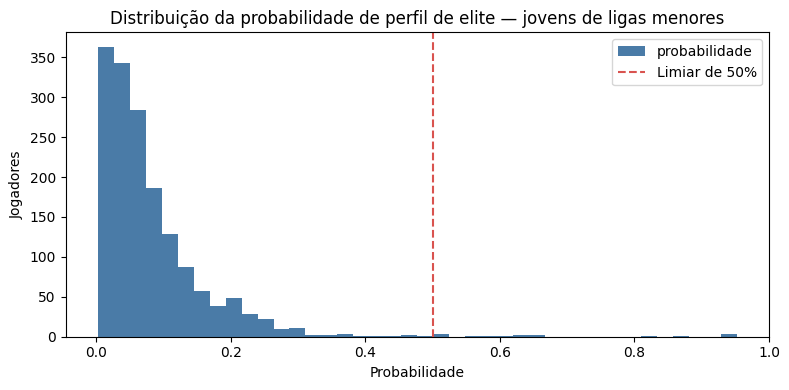

In [30]:
plt.figure(figsize=(8, 4))
jovens_fora['probabilidade'].plot(kind='hist', bins=40, color='#4a7ba7')
plt.axvline(0.5, color='#d9534f', linestyle='--', linewidth=1.5, label='Limiar de 50%')
plt.title('Distribuição da probabilidade de perfil de elite — jovens de ligas menores')
plt.xlabel('Probabilidade')
plt.ylabel('Jogadores')
plt.legend()
plt.tight_layout()
plt.show()

**Leitura do resultado:**

A grande maioria dos jovens concentra-se em probabilidades baixas, o que é esperado — o modelo não distribui rótulos de elite indiscriminadamente. Apenas uma fração reduzida ultrapassa o limiar de 50%, e é justamente essa fração que interessa à observação técnica.

Vale reforçar a limitação: o modelo indica **compatibilidade técnica atual** com o nível de elite, não previsão de desenvolvimento futuro. Um jogador apontado pode não evoluir; um jogador fora da lista pode se desenvolver. A ferramenta serve para direcionar a atenção de observadores, não para substituí-los.

## 18. Escrita do Modelo — 23/09/2026

### 18.1 Fundamentação do Algoritmo

O **SVM** traça uma fronteira que separa as duas classes com a maior margem possível. Os pontos mais próximos dessa fronteira são os **vetores de suporte** — são eles que a definem, não todos os dados.

Quando uma reta não basta, o **kernel** permite traçar fronteiras curvas.

Aqui o modelo usa 47 variáveis por jogador para separar atletas de ligas de elite dos de divisões menores.

### 18.2 Especificação do Modelo Final

- **Algoritmo:** Support Vector Classifier (`sklearn.svm.SVC`)
- **Kernel:** RBF (*Radial Basis Function*)
- **C:** 1
- **gamma:** `'scale'`
- **random_state:** 42
- **Variáveis preditoras:** 47
- **Registros de treino:** 3.805
- **Registros de teste:** 952
- **Pré-processamento:** `StandardScaler` ajustado no treino
- **Seleção de hiperparâmetros:** `GridSearchCV`, 12 combinações × 5 dobras

### 18.3 Justificativa dos Hiperparâmetros

**`kernel='rbf'`** — o GridSearchCV testou os kernels linear e RBF. O RBF venceu na validação cruzada, o que indica que a fronteira entre os níveis competitivos não é linear: não existe um corte simples em nenhum atributo que separe os grupos. Um jogador pode compensar reação mais baixa com passe superior, e o RBF captura esse tipo de combinação.

**`C=1`** — o parâmetro controla a penalidade por erro de classificação no treino. Valores altos forçam o modelo a acertar quase todos os exemplos, produzindo fronteiras irregulares que não generalizam. A busca selecionou o menor valor testado, sinal de que uma fronteira mais suave produz melhor desempenho em dados novos — comportamento esperado quando há sobreposição real entre as classes.

**`gamma='scale'`** — define o alcance de influência de cada amostra sobre a fronteira. O valor `'scale'` calcula automaticamente `1 / (n_features × variância)`, adaptando-se à escala dos dados. Valores fixos mais altos foram testados e produziram resultado inferior, pois tornam a fronteira excessivamente sensível a pontos individuais.

### 18.4 Métricas de Avaliação

Adotamos quatro métricas, cada uma respondendo a uma pergunta distinta:

- **Acurácia** — proporção de acertos sobre o total. É interpretável, mas insuficiente isolada: em bases desbalanceadas, um modelo que ignora a classe minoritária ainda registra acurácia alta. Por isso a comparamos sempre ao baseline de 70,17%.

- **Precisão** — dos jogadores que o modelo apontou como perfil de elite, quantos realmente eram. Responde ao custo do falso positivo.

- **Sensibilidade (recall)** — dos jogadores que realmente eram de elite, quantos o modelo encontrou. Responde ao custo do falso negativo.

- **F1-score** — média harmônica entre precisão e sensibilidade, útil para comparar configurações que equilibram as duas de formas diferentes.

A **matriz de confusão** complementa as métricas ao mostrar a distribuição dos erros: permite verificar se o modelo utiliza ambas as classes ou se colapsou na majoritária.

In [31]:
# Consolidação das métricas do modelo final
resumo = pd.DataFrame({
    'Métrica': ['Acurácia', 'Baseline', 'Ganho sobre baseline',
                'Validação cruzada', 'Precisão (elite)', 'Sensibilidade (elite)',
                'F1-score (elite)'],
    'Valor': [
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{y_test.value_counts(normalize=True).max():.4f}",
        f"{(accuracy_score(y_test, y_pred) - y_test.value_counts(normalize=True).max())*100:.2f} p.p.",
        f"{grid_search.best_score_:.4f}",
        f"{classification_report(y_test, y_pred, output_dict=True)['1']['precision']:.3f}",
        f"{classification_report(y_test, y_pred, output_dict=True)['1']['recall']:.3f}",
        f"{classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']:.3f}",
    ]
})

print("=== RESUMO DO MODELO FINAL ===")
print(resumo.to_string(index=False))
print()
print("Hiperparâmetros:", grid_search.best_params_)
print("Vetores de suporte:", modelo.n_support_.sum(), f"de {len(X_train)} amostras de treino")

=== RESUMO DO MODELO FINAL ===
              Métrica      Valor
             Acurácia     0.8803
             Baseline     0.7017
 Ganho sobre baseline 17.86 p.p.
    Validação cruzada     0.8857
     Precisão (elite)      0.894
Sensibilidade (elite)      0.680
     F1-score (elite)      0.772

Hiperparâmetros: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Vetores de suporte: 1335 de 3805 amostras de treino


### 18.5 Interpretação do Modelo

O modelo apoia a decisão em 1.335 vetores de suporte — os jogadores próximos da fronteira entre os dois níveis, onde estão os casos ambíguos.

Com 88,03% contra baseline de 70,17%, o modelo aprendeu um padrão real. A precisão de 0,894 na classe elite significa que ele acerta em quase nove de cada dez indicações, o que serve bem para scouting. A sensibilidade de 0,680 mostra que deixa escapar um terço dos jogadores de elite — aceitável, já que o objetivo é reduzir a lista com confiabilidade, não encontrar todos.

## 19. Conclusão

**Resultado obtido:**

- Acurácia no teste: **88,03%**
- Baseline: 70,17%
- Ganho: **17,9 pontos percentuais**
- Hiperparâmetros: `C=1`, `gamma='scale'`, `kernel='rbf'`
- Validação cruzada: 88,57%

**Principais achados:**

1. **Leitura de jogo supera atributos físicos.** Reação (0,63), passe curto (0,56), compostura (0,55) e controle de bola (0,53) lideram. Ritmo e força ficam bem abaixo — o alto nível não se define por capacidade atlética.

2. **Goleiros usam escala incompatível.** As colunas reaproveitam os nomes dos jogadores de linha mas medem outras habilidades: `Dribbling` vale 13,1 para goleiros contra 61,9 para os demais. Mantê-los faria o modelo aprender a distinguir posições, não nível competitivo.

3. **A validação externa confirma o aprendizado.** Jovens que já atuam em ligas de elite recebem probabilidades altas sem terem participado do treinamento — o modelo capturou o padrão técnico, não memorizou a amostra.

4. **Precisão ou cobertura é decisão de negócio.** O balanceamento eleva a sensibilidade de 0,680 para 0,817, mas derruba a precisão de 0,894 para 0,748. Para scouting, priorizamos a precisão.